### Hito 3:

### Segunda Iteración de Limpieza: Corrección de Inconsistencias

Tras una revisión más profunda de los datos, se detectaron nuevas inconsistencias
que no fueron cubiertas en la primera pasada de limpieza:

- **Países**: Variantes como "Arg", "Arg.", "ARG", "Chl", "CHL", "Peru", "PERU"
  que el .title() no pudo normalizar.
- **Categorías**: Valores "Nan" (242 registros) que llegaron como string y no como
  NaN, por lo que fillna() no los capturó. Se recuperan usando la subcategoría
  como referencia, ya que existe una relación 1 a 1 entre subcategoría y categoría.
- **Categoría "Electronica"** (19 registros): Error de tipeo sin acento.
- **Método de Pago**: Variantes como "Debito", "Credito", "Efect", "Transf", etc.


In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataframe = pd.read_csv("data/dataset_final.csv")

cat_por_sub = {
    'Iluminación': 'Hogar', 'Cocina': 'Hogar', 'Decoración': 'Hogar', 'Muebles': 'Hogar',
    'Caballero': 'Ropa', 'Calzado': 'Ropa', 'Dama': 'Ropa', 'Infantil': 'Ropa',
    'Accesorios': 'Electrónica', 'Celulares': 'Electrónica',
    'Laptops': 'Electrónica', 'Tablets': 'Electrónica'
}
mask_nan_cat = dataframe['Categoria'] == 'Nan'
dataframe.loc[mask_nan_cat, 'Categoria'] = dataframe.loc[mask_nan_cat, 'Subcategoria'].map(cat_por_sub)
# Las que por casualidad queden sin mapear → Otros
dataframe['Categoria'] = dataframe['Categoria'].replace('Nan', 'Otros')

# 2. Normalizar países
pais_map = {
    'Argentina': 'Argentina', 'Arg': 'Argentina', 'Arg.': 'Argentina',
    'ARG': 'Argentina', 'arg': 'Argentina', 'arg.': 'Argentina', 'argentina': 'Argentina',
    'Chile': 'Chile', 'Chl': 'Chile', 'CHL': 'Chile', 'chl': 'Chile', 'chile': 'Chile',
    'Perú': 'Perú', 'Peru': 'Perú', 'PERU': 'Perú', 'peru': 'Perú'
}
dataframe['Pais'] = dataframe['Pais'].map(pais_map)

# 3. Normalizar categoría Electronica → Electrónica
dataframe['Categoria'] = dataframe['Categoria'].replace('Electronica', 'Electrónica')

# 4. Normalizar métodos de pago
pago_map = {
    'Debito': 'Débito', 'DEBITO': 'Débito', 'debito': 'Débito',
    'Credito': 'Crédito', 'CREDITO': 'Crédito', 'credito': 'Crédito',
    'Efect': 'Efectivo', 'Efect.': 'Efectivo', 'efect': 'Efectivo',
    'efectivo': 'Efectivo', 'efect.': 'Efectivo',
    'Transf': 'Transferencia', 'Transf.': 'Transferencia',
    'transf': 'Transferencia', 'transferencia': 'Transferencia',
    "Nan" : "No Identificado"
}
dataframe['Metodo_Pago'] = dataframe['Metodo_Pago'].replace(pago_map)

#Limpieza de ciudad NaN a Sin Especificar
dataframe['Ciudad'] = dataframe['Ciudad'].replace('Nan', 'Sin Especificar')

dataframe.to_csv("data/dataset_limpio.csv")


## Creacion de Graficos
###  1. **¿Qué categorías de productos dejan mayor margen de ganancia por país?** 

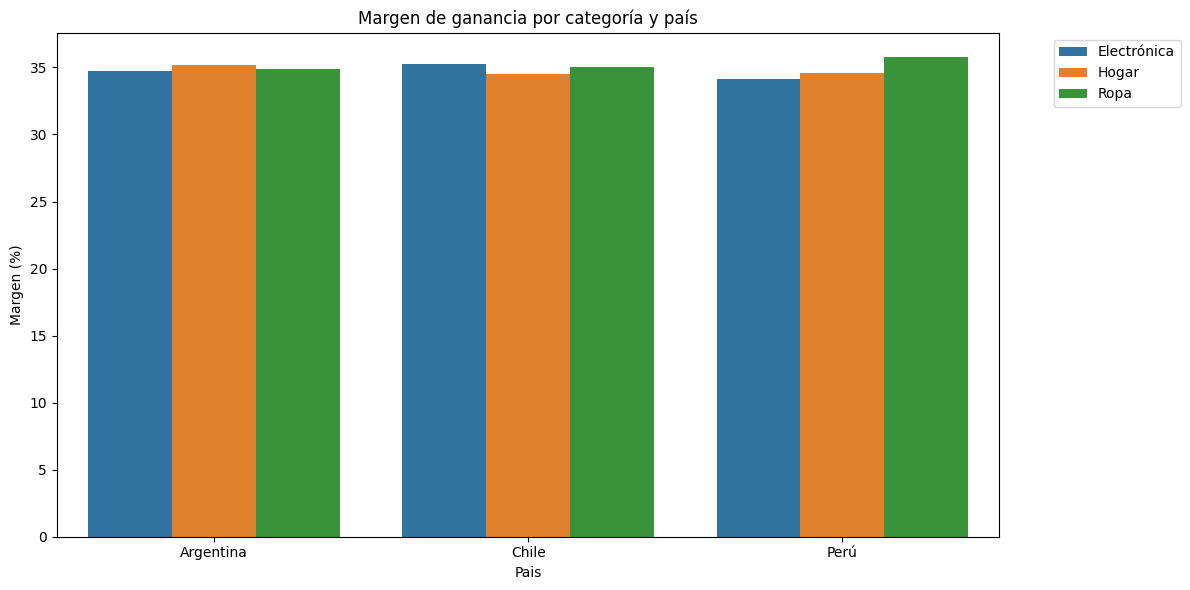

In [74]:
# Creamos columna de margen porcentual a partir de ganancia bruta y venta total
dataframe["Margen_Pct"] = (dataframe["Ganancia_Bruta"] / dataframe["Venta_Total"]) * 100

# Agrupacion por Pais + Categoria

grupo = dataframe.groupby(["Pais", "Categoria"])[["Ganancia_Bruta", "Venta_Total"]].sum().reset_index()
grupo["Margen_Pct"] = (grupo["Ganancia_Bruta"] / grupo["Venta_Total"]) * 100

grupo.head()

plt.figure(figsize=(12, 6))
sns.barplot(data=grupo, x='Pais', y='Margen_Pct', hue='Categoria')
plt.title('Margen de ganancia por categoría y país')
plt.ylabel('Margen (%)')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Análisis
- El gráfico muestra que no hay una aplia diferencia entre los márgenes de ganancia en los 3 países, sino diferencias mínimas:
- Argentina muestra un margen muy pequeño en Hogar
- Chile tiene margen superior muy similar en Electrónica y Ropa
- Perú es el único páis donde se ve un poco mas de diferencia en la categoría Ropa

Todos los países tienen categorías superiores diferentes pero la diferencia es muy poca

### 2.  **¿El método de pago influye en la cantidad total de productos comprados y el total gastado?**


              Cantidad                                               \
                 count      mean       std  min  25%  50%  75%  max   
Metodo_Pago                                                           
Crédito         2954.0  4.652674  2.523150  0.0  3.0  4.0  7.0  9.0   
Débito          2913.0  4.757981  2.516865  1.0  3.0  5.0  7.0  9.0   
Efectivo        2848.0  4.729635  2.534470  0.0  3.0  5.0  7.0  9.0   
Transferencia   3009.0  4.729478  2.528415  1.0  3.0  5.0  7.0  9.0   

              Venta_Total                                                 \
                    count        mean         std   min      25%     50%   
Metodo_Pago                                                                
Crédito            2954.0  267.800823  209.838217  0.00  111.030  214.13   
Débito             2913.0  275.263368  215.187178  6.53  116.400  220.41   
Efectivo           2848.0  271.295864  212.343095  0.00  112.495  216.31   
Transferencia      3009.0  273.420372  213.563

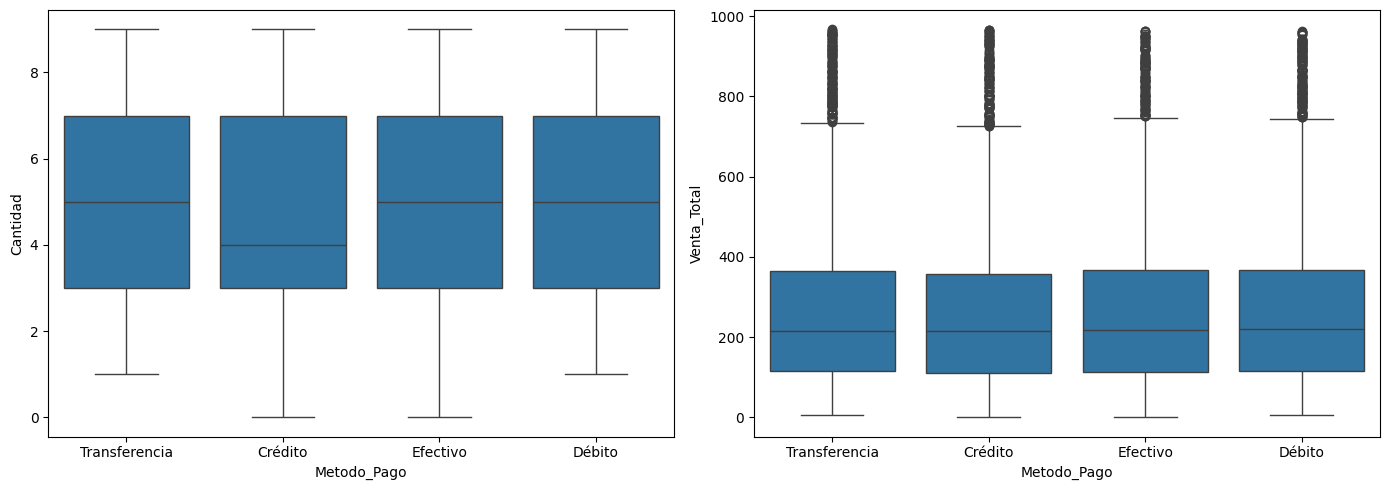

In [75]:
# Quitamos los metodos de pago no identificados para el analisis
mascara_no_identificados = dataframe["Metodo_Pago"] != "No Identificado"

df_p = dataframe[mascara_no_identificados].copy()
print(df_p.groupby("Metodo_Pago")[["Cantidad", "Venta_Total"]].describe())


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_p, x='Metodo_Pago', y='Cantidad', ax=axes[0])
sns.boxplot(data=df_p, x='Metodo_Pago', y='Venta_Total', ax=axes[1])
plt.tight_layout()
plt.show()

## Análisis
- Las medianas de cantidad y venta total son prácticamente iguales entre los diferentes medios de pago
- Los rangos también se superponen casi por completo
- Esto nos indica que **No se observa una influencia relevante del método de pago** ni en la cantidad de productos comprados ni en el total gastado

### 3. **¿Cuál es el método de pago que domina las transacciones de alto valor en cada país y cómo influye esto en la venta total mensual?**


Umbral (P85): $478.01
Metodo_Pago  Crédito  Débito  Efectivo  Transferencia
Pais                                                 
Argentina        144     148       144            164
Chile            145     154       158            157
Perú             145     146       117            126


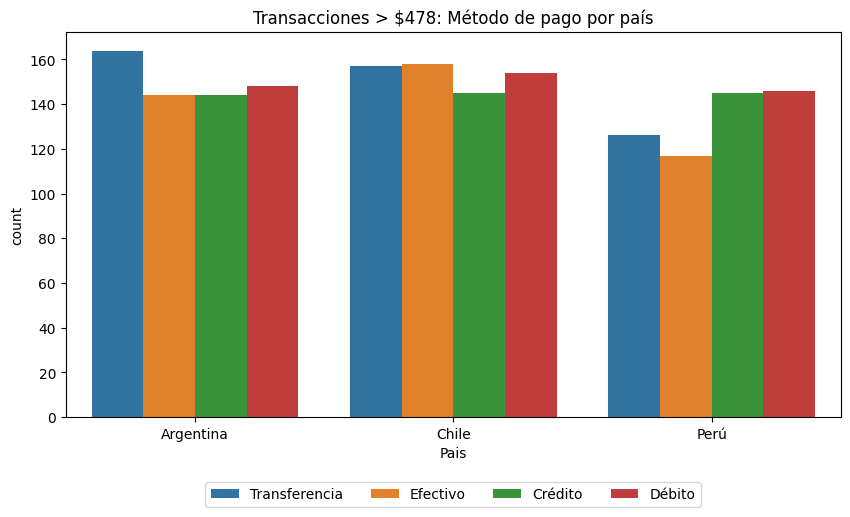

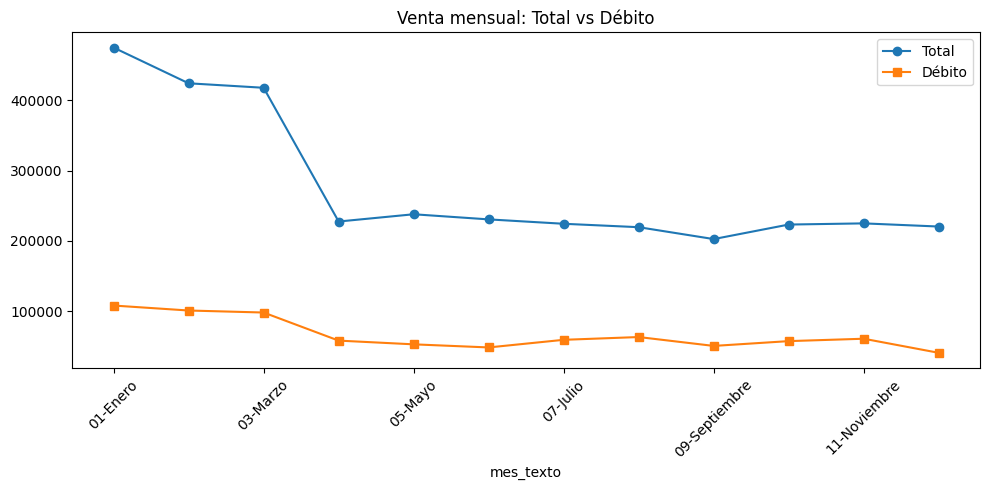

Débito: 24.1% de la venta total


In [76]:
# 1. Umbral
umbral = dataframe['Venta_Total'].quantile(0.85)
print(f"Umbral (P85): ${umbral:.2f}")

# 2. Filtrar altas transacciones
df_alto = dataframe[(dataframe['Venta_Total'] > umbral) & (dataframe['Metodo_Pago'] != 'No Identificado')]

# 3. Método dominante
print(df_alto.groupby('Pais')['Metodo_Pago'].value_counts().unstack().fillna(0))

# 4. Bar plot
plt.figure(figsize=(10, 5))
sns.countplot(data=df_alto, x='Pais', hue='Metodo_Pago')
plt.title(f'Transacciones > ${umbral:.0f}: Método de pago por país')
plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4)
plt.show()

# 5. Método más usado globalmente
metodo_top = df_alto['Metodo_Pago'].value_counts().index[0]

# 6. Venta mensual
total_mensual = dataframe.groupby('mes_texto')['Venta_Total'].sum()
top_mensual = dataframe[dataframe['Metodo_Pago'] == metodo_top].groupby('mes_texto')['Venta_Total'].sum()

plt.figure(figsize=(10, 5))
total_mensual.plot(label='Total', marker='o')
top_mensual.plot(label=metodo_top, marker='s')
plt.title(f'Venta mensual: Total vs {metodo_top}')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 7. % que representa
print(f"{metodo_top}: {top_mensual.sum()/total_mensual.sum()*100:.1f}% de la venta total")

### Análisis
Se definieron transacciones de alto valor como aquellas superiores al percentil 85 de Venta_Total. 

Débito Resulto el método mas frecuente de este segmento aunque solo representa el 24% del total mensual. Éste se mantiene estable aun en los meses de mayores ventas (Enero-Marzo).

Respecto a las diferencias por país:
- Argentina domina **Transferencia** en altas transacciones
- Chile tiene distribución relativamente uniforme 
- Perú tiene mayoría en **Crédito** y **Débito**

### 4.  **¿Hay ciudades en cada país donde la diferencia entre el costo de los productos y el precio de venta sea significativamente menor, afectando la rentabilidad?**


=== Ciudades con margen menor al promedio de su país ===
     Pais       Ciudad  Margen_Unitario  Bajo_Promedio
Argentina Buenos Aires        21.736205           True
    Chile     Santiago        22.141247           True
     Perú         Lima        21.647080           True


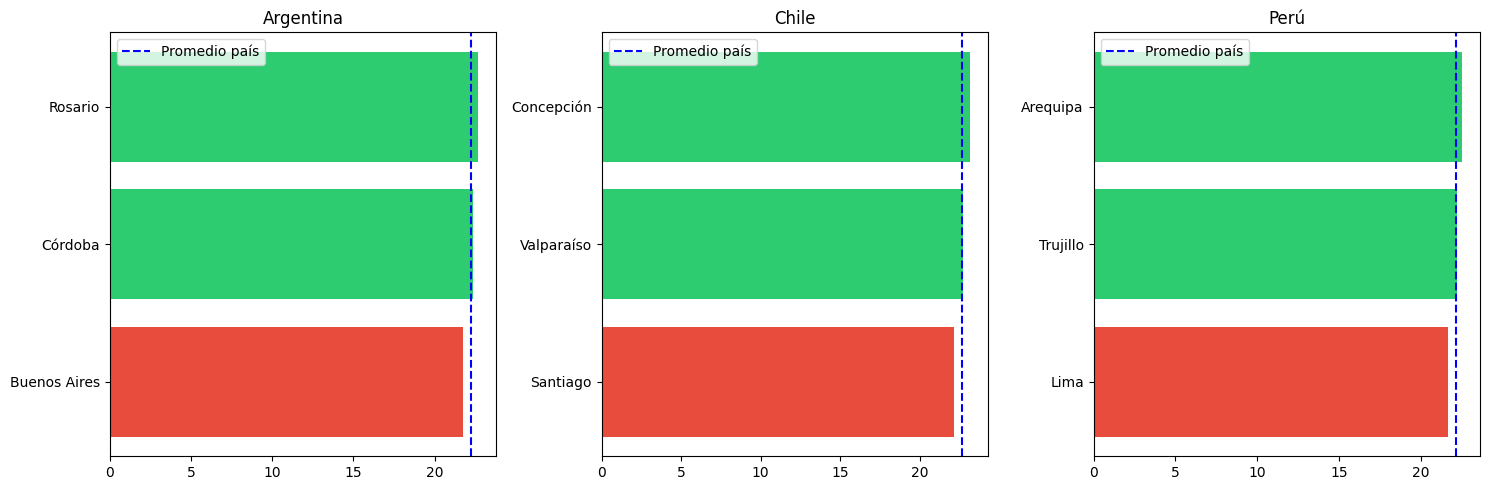

In [77]:
df_c = dataframe[dataframe['Ciudad'] != 'Sin Especificar'].copy()

# Margen unitario
df_c['Margen_Unitario'] = df_c['Precio_Unitario'] - df_c['Costo_Unitario']

# Promedio por ciudad
ciudades = df_c.groupby(['Pais', 'Ciudad'])['Margen_Unitario'].mean().reset_index()

# Promedio por país
prom_pais = df_c.groupby('Pais')['Margen_Unitario'].mean()

# Identificar ciudades bajo el promedio
ciudades['Bajo_Promedio'] = ciudades.apply(
    lambda r: r['Margen_Unitario'] < prom_pais[r['Pais']], axis=1
)

print("=== Ciudades con margen menor al promedio de su país ===")
print(ciudades[ciudades['Bajo_Promedio']].to_string(index=False))

# Gráfico
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, pais in zip(axes, sorted(df_c['Pais'].unique())):
    data = ciudades[ciudades['Pais'] == pais].sort_values('Margen_Unitario')
    colores = ['#e74c3c' if v < prom_pais[pais] else '#2ecc71' for v in data['Margen_Unitario']]
    ax.barh(data['Ciudad'], data['Margen_Unitario'], color=colores)
    ax.axvline(prom_pais[pais], color='blue', linestyle='--', label='Promedio país')
    ax.set_title(pais)
    ax.legend()

plt.tight_layout()
plt.show()

### Anlálisis
No se identificaron ciudades con rentabilidad significativamente menor. 

Todos los márgenes por ciudad son muy cercanos al promedio de su país, lo que sugiere que la rentabilidad es uniforme a nivel geográfico y no hay concentración de baja rentabilidad en ninguna ciudad específica.